In [79]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from matplotlib import pyplot as plt

from sk_decoder import RetinaDecoder
from sk_train_decoder import RGCDataset
from sk_utils import Utils as u

In [80]:
results = torch.load("/home/rotation/Desktop/LNP_LN_LN_Models/test_weights_final.pt")
results.keys()

dict_keys(['model_state_dict', 'train_loss_history', 'val_loss_history'])

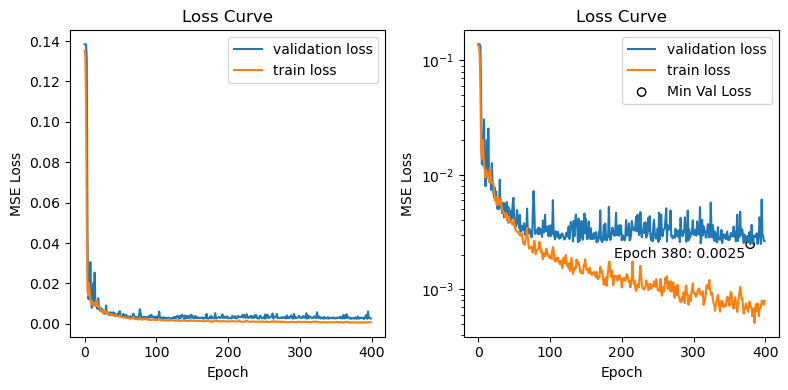

In [97]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].plot(results["val_loss_history"], label="validation loss")
ax[0].plot(results["train_loss_history"], label="train loss")
ax[0].legend()

ax[0].set_title("Loss Curve")
ax[0].set_ylabel("MSE Loss")
ax[0].set_xlabel("Epoch")

ax[1].plot(results["val_loss_history"], label="validation loss")
ax[1].plot(results["train_loss_history"], label="train loss")

# show the minimum validation loss model
ax[1].scatter(379, min(results["val_loss_history"]), edgecolor="black", marker="o", facecolor="none", label="Min Val Loss")
ax[1].text(379-190, min(results["val_loss_history"])-0.0006, f"Epoch 380: {min(results['val_loss_history']):.4f}")
ax[1].legend()

ax[1].set_yscale("log")
ax[1].set_title("Loss Curve")
ax[1].set_ylabel("MSE Loss")
ax[1].set_xlabel("Epoch")

fig.set_tight_layout(True)
plt.show()

In [86]:
# Let's see if we can rebuild some of the input images (and if we can try to rebuild some out of distribution images)
# 1. Load Configurations
train_cfg = u.read_params("params_training.yaml")
device = "cuda" if torch.cuda.is_available() else "cpu"

# 2. Data Preparation
dataset = RGCDataset("test_activations.pt", "params_training.yaml")

# Validation split
val_split = train_cfg.get("validation_split", 0.1)
val_size = int(len(dataset) * val_split)
train_size = len(dataset) - val_size
train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=train_cfg.get("batch_size", 64), shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=train_cfg.get("batch_size", 64), shuffle=False, num_workers=0)

# 3. Model Initialization
n_mosaics, max_n_cells, _ = dataset.firing_rates.shape
decoder_params = {
    "n_cells": n_mosaics * max_n_cells * dataset.input_window,
    "frame_shape": dataset.video_info["shape"][1:],
    "num_blocks": train_cfg.get("num_blocks", 4),
    "num_kernels": train_cfg.get("num_kernels", 64),
    "bias": train_cfg.get("bias", False)
}

model = RetinaDecoder(decoder_params).to(device)
model.load_state_dict(torch.load("test_weights.pt")["model_state_dict"])
model.eval()

Loading video from /home/rotation/Desktop/LNP_LN_LN_Models/lnp_naturalmovies/Video_2.mp4...
Full video loaded: 898 frames, 1080x1920 resolution, 30.000011135861595 FPS.
Cropping video to 128x128 starting at (350, 500)...


RetinaDecoder(
  (w): Linear(in_features=6404, out_features=65536, bias=True)
  (mid_block): Sequential(
    (0): Conv2d(1024, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BF_batchNorm()
    (2): ReLU(inplace=True)
    (3): Conv2d(1024, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  )
  (upsample): ModuleDict(
    (3): ConvTranspose2d(1024, 512, kernel_size=(2, 2), stride=(2, 2), bias=False)
    (2): ConvTranspose2d(512, 256, kernel_size=(2, 2), stride=(2, 2), bias=False)
    (1): ConvTranspose2d(256, 128, kernel_size=(2, 2), stride=(2, 2), bias=False)
    (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2), bias=False)
  )
  (decoder): ModuleDict(
    (3): Sequential(
      (0): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BF_batchNorm()
      (2): ReLU(inplace=True)
      (3): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BF_b

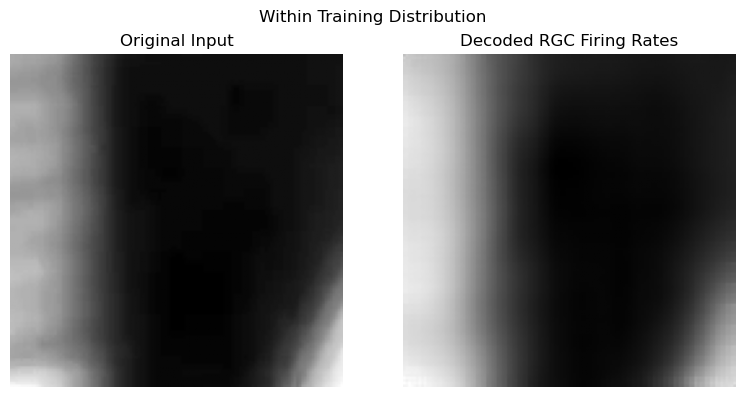

In [110]:
for x,y in train_loader:
    break
x.shape, y.shape

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ex = 63

ax[0].imshow(y[ex].squeeze(0), cmap="gray")
ax[0].set_title("Original Input")

# do the forward pass
x_cuda = x.to(device)
Y_pred = model(x_cuda)
ax[1].imshow(Y_pred.cpu().detach().numpy()[ex].squeeze(0), cmap="gray")
ax[1].set_title("Decoded RGC Firing Rates")

for a in ax:
    a.axis("off")

fig.suptitle("Within Training Distribution")
fig.set_tight_layout(True)
plt.show()

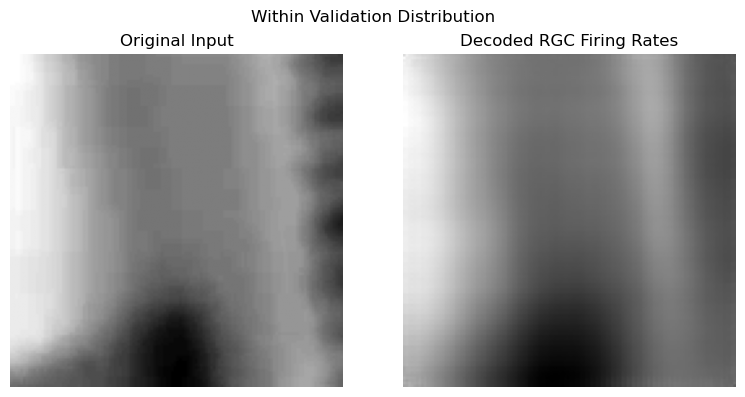

In [107]:
# what about something from the validation set?
for x,y in val_loader:
    break
x.shape, y.shape

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ex = 39

ax[0].imshow(y[ex].squeeze(0), cmap="gray")
ax[0].set_title("Original Input")

# do the forward pass
x_cuda = x.to(device)
Y_pred = model(x_cuda)
ax[1].imshow(Y_pred.cpu().detach().numpy()[ex].squeeze(0), cmap="gray")
ax[1].set_title("Decoded RGC Firing Rates")

for a in ax:
    a.axis("off")

fig.suptitle("Within Validation Distribution")
fig.set_tight_layout(True)
plt.show()

In [ ]:
# what about something entirely out of distribution
# let's try something a bit crazy:
# regenerating the entire video by creating patches from every portion of the video
!conda activate lnp_torch
!python sk_generate_activations.py